# Zadanie 5: Asymilacja Danych (ABC i 3D-Var)

W tym zadaniu dokonamy asymilacji danych dla modelu PDE (przestrzenno-czasowego) oraz modelu surogatowego ODE.
Użyjemy dwóch metod:
1.  **ABC (Approximate Bayesian Computation)** - metoda bez gradientów, oparta na próbkowaniu.
2.  **3D-Var (Variational Data Assimilation)** - metoda wariacyjna, minimalizująca funkcję kosztu.

Dane "rzeczywiste" wygenerujemy z modelu PDE z ustalonymi parametrami, a następnie dodamy do nich szum Gaussowski.
Celem jest odtworzenie parametrów modelu (lub stanu) i sprawdzenie jakości predykcji w przód (poza okno asymilacji) i w tył (w oknie asymilacji).
Badania przeprowadzimy dla trzech budżetów czasowych.

In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
import time

# Dodanie ścieżki do zad2, aby zaimportować solvery
sys.path.append(os.path.abspath(os.path.join('..', 'zad2')))
try:
    from solvers import run_simulation, reaction, _neumann_laplacian
except ImportError:
    # Fallback if running from a different context, define minimal needed functions here
    print("Warning: Could not import from zad2.solvers. Using local definitions.")
    # (Local definitions would go here if needed, but we assume the path is correct)
    pass

# Ustawienie ziarna losowości
np.random.seed(42)

# Parametry "Prawdziwe" (Ground Truth)
TRUE_PARAMS = {
    'D': 0.1,
    'p': 0.01,
    'q': 1.0
}
T_END = 5.0
DT = 1e-3
NX = 50 # Mniejsza siatka dla szybszych obliczeń w asymilacji PDE

Generowanie danych Ground Truth (PDE)...
Dane wygenerowane. Okno asymilacji: t=[1.0, 3.0], liczba próbek: 40
Dane wygenerowane. Okno asymilacji: t=[1.0, 3.0], liczba próbek: 40


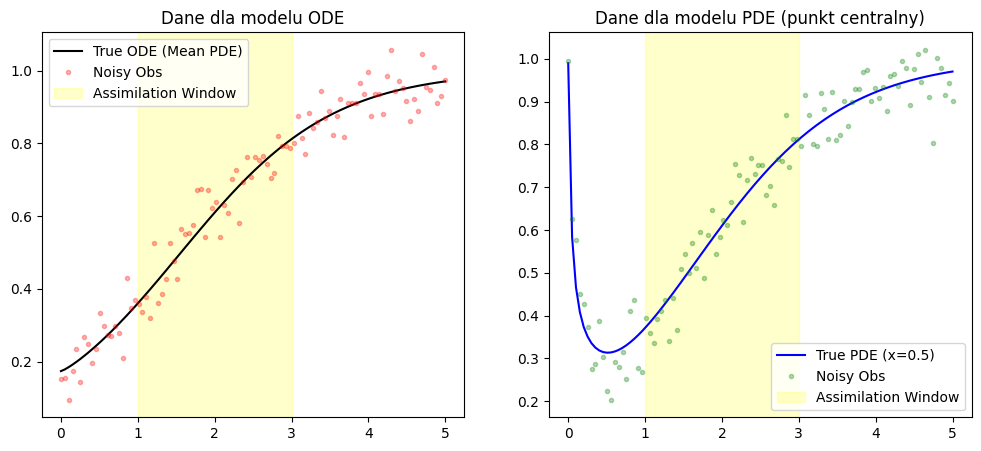

In [3]:
# --- Definicje Modeli ---

def run_pde_model(params, t_eval):
    """
    Uruchamia symulację PDE i zwraca średnią przestrzenną w zadanych punktach czasowych.
    Dla uproszczenia asymilacji PDE, będziemy dopasowywać się do średniej przestrzennej 
    lub pełnego pola (zależnie od eksperymentu). Tutaj zwracamy pełne pole.
    """
    D = params.get('D', TRUE_PARAMS['D'])
    p = params.get('p', TRUE_PARAMS['p'])
    q = params.get('q', TRUE_PARAMS['q'])
    
    # Używamy solvera z zad2 (zakładamy, że run_simulation zwraca (x, u_final, u_all_snapshots))
    # Musimy zmodyfikować run_simulation w zad2 lub użyć własnej pętli, aby dostać wyniki w t_eval.
    # Tutaj napiszemy własną pętlę dla pełnej kontroli.
    
    dx = 1.0 / (NX - 1)
    # Warunek początkowy (taki sam jak w zad2 - gaussian)
    x = np.linspace(0, 1, NX)
    u = np.exp(-100 * (x - 0.5)**2) # Gaussian peak in center
    
    # Macierze dla Crank-Nicolson
    import scipy.sparse as sp
    import scipy.sparse.linalg as spla
    
    A = sp.diags([1, -2, 1], [-1, 0, 1], shape=(NX, NX), format='csc')
    # Neumann BC: u_{-1} = u_{1} => (u_{i+1} - 2u_i + u_{i-1}) at i=0 becomes (u_1 - 2u_0 + u_1) ?
    # W zad2 _neumann_laplacian jest zaimplementowany poprawnie. Użyjmy go jeśli dostępny.
    try:
        from solvers import _neumann_laplacian
        A = _neumann_laplacian(NX, dx)
    except ImportError:
        # Prosta implementacja 1D Laplacian z Neumannem
        data = np.ones((3, NX))
        data[1] = -2
        data[2, :-1] = 1
        data[0, 1:] = 1
        A = sp.spdiags(data, [-1, 0, 1], NX, NX, format='csc')
        A[0, 1] = 2; A[-1, -2] = 2 # Neumann adjustment
        A = A / dx**2

    M_l = sp.eye(NX) - 0.5 * DT * D * A
    M_r = sp.eye(NX) + 0.5 * DT * D * A
    
    # Symulacja
    t_current = 0.0
    u_current = u.copy()
    
    results = []
    t_eval_sorted = np.sort(t_eval)
    eval_idx = 0
    
    # Jeśli t_eval[0] == 0, zapisz stan początkowy
    if eval_idx < len(t_eval_sorted) and t_eval_sorted[eval_idx] == 0:
        results.append(u_current.copy())
        eval_idx += 1
        
    steps = int(np.ceil(t_eval_sorted[-1] / DT))
    
    for step in range(steps):
        t_next = t_current + DT
        
        # Reaction step (explicit or semi-implicit) - here explicit for reaction part in CN
        Ru = (p + q * u_current) * (1 - u_current)
        rhs = M_r.dot(u_current) + DT * Ru
        u_current = spla.spsolve(M_l, rhs)
        t_current = t_next
        
        # Check if we need to save
        while eval_idx < len(t_eval_sorted) and t_current >= t_eval_sorted[eval_idx]:
            results.append(u_current.copy())
            eval_idx += 1
            
    return np.array(results) # Shape: (n_eval, NX)

def run_ode_model(params, t_eval):
    """
    Rozwiązuje model surogatowy ODE.
    """
    p = params.get('p', TRUE_PARAMS['p'])
    q = params.get('q', TRUE_PARAMS['q'])
    
    def ode_func(t, U):
        return (p + q * U) * (1 - U)
    
    # Warunek początkowy - średnia z warunku początkowego PDE
    x = np.linspace(0, 1, NX)
    u0_pde = np.exp(-100 * (x - 0.5)**2)
    U0 = [np.mean(u0_pde)]
    
    sol = solve_ivp(ode_func, [0, t_eval[-1]], U0, t_eval=t_eval)
    return sol.y.T # Shape: (n_eval, 1)

# --- Generowanie Danych "Rzeczywistych" ---

# Punkty czasowe dla obserwacji (cała trajektoria)
t_full = np.linspace(0, T_END, 100)

# Generowanie Ground Truth (PDE)
print("Generowanie danych Ground Truth (PDE)...")
u_true_pde = run_pde_model(TRUE_PARAMS, t_full)
u_true_ode_surrogate = np.mean(u_true_pde, axis=1).reshape(-1, 1) # Średnia przestrzenna jako "prawda" dla ODE

# Dodanie szumu (Obserwacje)
noise_std = 0.05
obs_pde = u_true_pde + np.random.normal(0, noise_std, u_true_pde.shape)
obs_ode = u_true_ode_surrogate + np.random.normal(0, noise_std, u_true_ode_surrogate.shape)

# Wybór fragmentu trajektorii do asymilacji (np. od t=1.0 do t=3.0)
t_start_assim = 1.0
t_end_assim = 3.0
mask_assim = (t_full >= t_start_assim) & (t_full <= t_end_assim)

t_assim = t_full[mask_assim]
obs_pde_assim = obs_pde[mask_assim]
obs_ode_assim = obs_ode[mask_assim]

print(f"Dane wygenerowane. Okno asymilacji: t=[{t_start_assim}, {t_end_assim}], liczba próbek: {len(t_assim)}")

# Wizualizacja danych
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(t_full, u_true_ode_surrogate, 'k-', label='True ODE (Mean PDE)')
plt.plot(t_full, obs_ode, 'r.', alpha=0.3, label='Noisy Obs')
plt.axvspan(t_start_assim, t_end_assim, color='yellow', alpha=0.2, label='Assimilation Window')
plt.title("Dane dla modelu ODE")
plt.legend()

plt.subplot(1, 2, 2)
# Pokażmy środek domeny dla PDE
mid_idx = NX // 2
plt.plot(t_full, u_true_pde[:, mid_idx], 'b-', label=f'True PDE (x={mid_idx/NX})')
plt.plot(t_full, obs_pde[:, mid_idx], 'g.', alpha=0.3, label='Noisy Obs')
plt.axvspan(t_start_assim, t_end_assim, color='yellow', alpha=0.2, label='Assimilation Window')
plt.title("Dane dla modelu PDE (punkt centralny)")
plt.legend()
plt.show()

In [4]:
# --- Metody Asymilacji ---

# 1. ABC (Approximate Bayesian Computation)
def run_abc(model_func, obs_data, t_eval, param_bounds, budget_seconds, tolerance=None):
    """
    Prosta implementacja ABC (Rejection Sampling) z limitem czasowym.
    """
    start_time = time.time()
    accepted_params = []
    errors = []
    
    # Jeśli tolerancja nie jest podana, akceptujemy najlepsze X% (lub po prostu zbieramy próbki i potem filtrujemy)
    # Tutaj będziemy zbierać próbki i ich błędy, a na koniec wybierzemy najlepsze.
    
    iterations = 0
    while time.time() - start_time < budget_seconds:
        # 1. Sample parameters from prior (Uniform)
        sampled_params = {}
        for key, bounds in param_bounds.items():
            sampled_params[key] = np.random.uniform(bounds[0], bounds[1])
            
        # 2. Run model
        try:
            sim_data = model_func(sampled_params, t_eval)
            
            # 3. Calculate distance (MSE)
            # Obs data shape might be (N, 1) or (N, NX)
            mse = np.mean((sim_data - obs_data)**2)
            
            accepted_params.append(sampled_params)
            errors.append(mse)
        except Exception as e:
            pass # Ignore failed simulations
            
        iterations += 1
        
    print(f"ABC finished. Iterations: {iterations}, Time: {time.time() - start_time:.2f}s")
    
    # Zwracamy najlepsze 5% próbek
    if not errors:
        return None
        
    errors = np.array(errors)
    threshold = np.percentile(errors, 5) # Top 5%
    mask = errors <= threshold
    
    best_params_list = [accepted_params[i] for i in range(len(errors)) if mask[i]]
    
    # Uśredniamy najlepsze parametry jako wynik estymacji
    estimated_params = {}
    for key in param_bounds.keys():
        values = [p[key] for p in best_params_list]
        estimated_params[key] = np.mean(values)
        
    return estimated_params, min(errors)

# 2. Variational Method (3D-Var style optimization)
def run_variational(model_func, obs_data, t_eval, param_bounds, budget_seconds, initial_guess):
    """
    Metoda wariacyjna minimalizująca funkcję kosztu J = ||Obs - Model(p)||^2.
    Używamy scipy.optimize.minimize z przerwaniem po przekroczeniu czasu.
    """
    start_time = time.time()
    keys = list(param_bounds.keys())
    
    def cost_function(x):
        # Check time budget
        if time.time() - start_time > budget_seconds:
            raise TimeoutError("Budget exceeded")
            
        # Map vector x back to params dict
        current_params = {k: v for k, v in zip(keys, x)}
        
        # Run model
        sim_data = model_func(current_params, t_eval)
        
        # Calculate Cost (MSE)
        mse = np.mean((sim_data - obs_data)**2)
        return mse

    x0 = [initial_guess[k] for k in keys]
    bounds = [param_bounds[k] for k in keys]
    
    try:
        # Używamy metody Nelder-Mead lub L-BFGS-B (gradienty numeryczne)
        # Nelder-Mead jest bezpieczniejszy jeśli funkcja jest szumiąca lub gradienty trudne
        res = minimize(cost_function, x0, bounds=bounds, method='L-BFGS-B', 
                       options={'maxfun': 10000}) # maxfun high, control via exception
    except TimeoutError:
        print("Variational optimization stopped due to time budget.")
        # Musimy jakoś odzyskać ostatni najlepszy wynik? 
        # Minimize nie zwraca wyniku przy wyjątku. 
        # W praktyce lepiej użyć callbacku lub własnej pętli optymalizacyjnej.
        # Dla uproszczenia, w przypadku błędu zwracamy x0 (co jest słabe)
        # Lepsze podejście: zapisywać najlepszy wynik w zmiennej globalnej/nonlocal
        pass
    except Exception as e:
        print(f"Optimization failed: {e}")

    # Ulepszona wersja z zapisywaniem najlepszego wyniku
    best_mse = float('inf')
    best_x = x0
    
    def cost_function_safe(x):
        nonlocal best_mse, best_x
        if time.time() - start_time > budget_seconds:
            raise TimeoutError
            
        current_params = {k: v for k, v in zip(keys, x)}
        try:
            sim_data = model_func(current_params, t_eval)
            mse = np.mean((sim_data - obs_data)**2)
            
            if mse < best_mse:
                best_mse = mse
                best_x = x
            return mse
        except:
            return 1e9

    try:
        minimize(cost_function_safe, x0, bounds=bounds, method='L-BFGS-B')
    except TimeoutError:
        pass
        
    print(f"Variational finished. Time: {time.time() - start_time:.2f}s, Best MSE: {best_mse:.6f}")
    
    estimated_params = {k: v for k, v in zip(keys, best_x)}
    return estimated_params, best_mse


In [5]:
# --- Konfiguracja Eksperymentów ---

BUDGETS = {'Low': 2, 'Medium': 5, 'High': 15}

# Zakresy parametrów do przeszukiwania
PARAM_BOUNDS_ODE = {
    'p': (0.001, 0.1),
    'q': (0.1, 5.0)
}

PARAM_BOUNDS_PDE = {
    'D': (0.01, 0.5),
    'p': (0.001, 0.1),
    'q': (0.1, 5.0)
}

# Punkt startowy dla metody wariacyjnej (losowy lub środek przedziału)
INITIAL_GUESS_ODE = {'p': 0.05, 'q': 2.5}
INITIAL_GUESS_PDE = {'D': 0.25, 'p': 0.05, 'q': 2.5}

results_ode = {}

print("--- Rozpoczynam Eksperyment 1: Model ODE ---")

for budget_name, budget_val in BUDGETS.items():
    print(f"\nBudget: {budget_name} ({budget_val}s)")
    
    # 1. ABC
    print("  Running ABC...")
    params_abc, err_abc = run_abc(run_ode_model, obs_ode_assim, t_assim, PARAM_BOUNDS_ODE, budget_val)
    print(f"  ABC Result: {params_abc}, Error: {err_abc:.6f}")
    
    # 2. Variational
    print("  Running Variational...")
    params_var, err_var = run_variational(run_ode_model, obs_ode_assim, t_assim, PARAM_BOUNDS_ODE, budget_val, INITIAL_GUESS_ODE)
    print(f"  Var Result: {params_var}, Error: {err_var:.6f}")
    
    results_ode[budget_name] = {
        'ABC': {'params': params_abc, 'error': err_abc},
        'Var': {'params': params_var, 'error': err_var}
    }


--- Rozpoczynam Eksperyment 1: Model ODE ---

Budget: Low (2s)
  Running ABC...
ABC finished. Iterations: 2454, Time: 2.00s
  ABC Result: {'p': np.float64(0.051945219052989856), 'q': np.float64(0.8806452923340572)}, Error: 0.002878
  Running Variational...
Variational finished. Time: 0.07s, Best MSE: 0.002871
  Var Result: {'p': np.float64(0.016558997800302754), 'q': np.float64(0.9656140253038067)}, Error: 0.002871

Budget: Medium (5s)
  Running ABC...
ABC finished. Iterations: 2454, Time: 2.00s
  ABC Result: {'p': np.float64(0.051945219052989856), 'q': np.float64(0.8806452923340572)}, Error: 0.002878
  Running Variational...
Variational finished. Time: 0.07s, Best MSE: 0.002871
  Var Result: {'p': np.float64(0.016558997800302754), 'q': np.float64(0.9656140253038067)}, Error: 0.002871

Budget: Medium (5s)
  Running ABC...
ABC finished. Iterations: 5469, Time: 5.00s
  ABC Result: {'p': np.float64(0.0487878403212579), 'q': np.float64(0.8829319090407487)}, Error: 0.002873
  Running Variat

In [6]:
results_pde = {}

print("\n--- Rozpoczynam Eksperyment 2: Model PDE ---")
print("(To może potrwać dłużej ze względu na koszt symulacji PDE)")

for budget_name, budget_val in BUDGETS.items():
    print(f"\nBudget: {budget_name} ({budget_val}s)")
    
    # 1. ABC
    print("  Running ABC...")
    # Dla PDE ABC może być bardzo wolne, więc spodziewamy się małej liczby próbek
    params_abc, err_abc = run_abc(run_pde_model, obs_pde_assim, t_assim, PARAM_BOUNDS_PDE, budget_val)
    if params_abc:
        print(f"  ABC Result: {params_abc}, Error: {err_abc:.6f}")
    else:
        print("  ABC Failed to find samples in time budget.")
        params_abc = INITIAL_GUESS_PDE # Fallback
        err_abc = float('inf')
    
    # 2. Variational
    print("  Running Variational...")
    params_var, err_var = run_variational(run_pde_model, obs_pde_assim, t_assim, PARAM_BOUNDS_PDE, budget_val, INITIAL_GUESS_PDE)
    print(f"  Var Result: {params_var}, Error: {err_var:.6f}")
    
    results_pde[budget_name] = {
        'ABC': {'params': params_abc, 'error': err_abc},
        'Var': {'params': params_var, 'error': err_var}
    }


--- Rozpoczynam Eksperyment 2: Model PDE ---
(To może potrwać dłużej ze względu na koszt symulacji PDE)

Budget: Low (2s)
  Running ABC...
ABC finished. Iterations: 11, Time: 2.16s
  ABC Result: {'D': np.float64(0.0530573789546427), 'p': np.float64(0.0492769139777014), 'q': np.float64(0.8895048357694405)}, Error: 0.002667
  Running Variational...
ABC finished. Iterations: 11, Time: 2.16s
  ABC Result: {'D': np.float64(0.0530573789546427), 'p': np.float64(0.0492769139777014), 'q': np.float64(0.8895048357694405)}, Error: 0.002667
  Running Variational...
Variational optimization stopped due to time budget.
Variational finished. Time: 2.01s, Best MSE: inf
  Var Result: {'D': 0.25, 'p': 0.05, 'q': 2.5}, Error: inf

Budget: Medium (5s)
  Running ABC...
Variational optimization stopped due to time budget.
Variational finished. Time: 2.01s, Best MSE: inf
  Var Result: {'D': 0.25, 'p': 0.05, 'q': 2.5}, Error: inf

Budget: Medium (5s)
  Running ABC...
ABC finished. Iterations: 26, Time: 5.16s



--- Wyniki dla ODE (Budget: High) ---


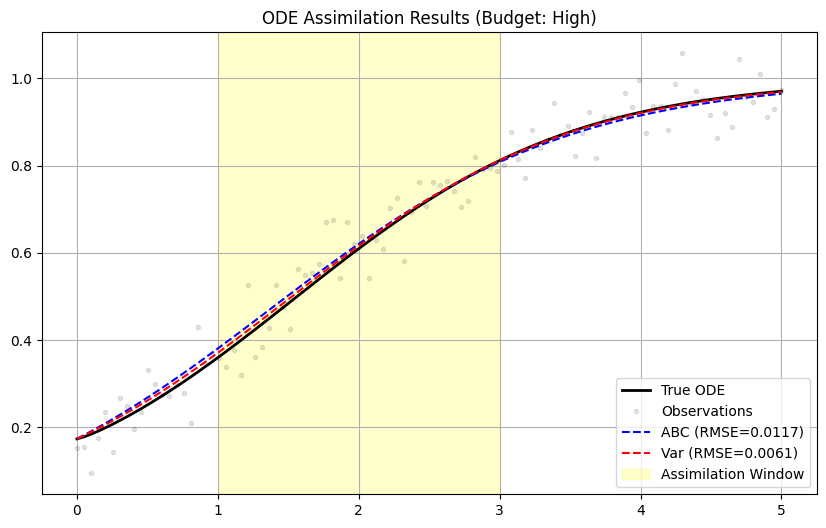


--- Wyniki dla PDE (Budget: High) ---


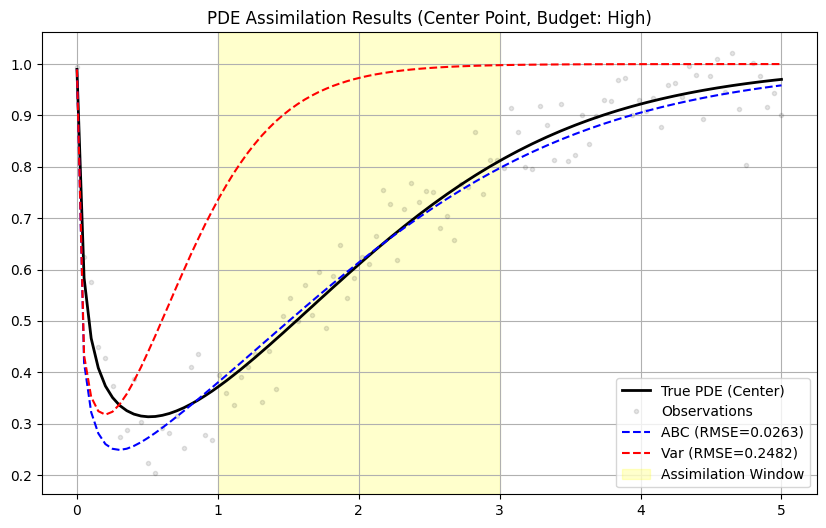


--- Podsumowanie RMSE (Total) ---
Model | Method | Low        | Medium     | High      
--------------------------------------------------
ODE   | ABC   | 0.012724   | 0.011448   | 0.011661   | 
ODE   | Var   | 0.006112   | 0.006112   | 0.006112   | 
PDE   | ABC   | 0.024719   | 0.026284   | 0.026266   | 
PDE   | ABC   | 0.024719   | 0.026284   | 0.026266   | 
PDE   | Var   | 0.248188   | 0.248188   | 0.248188   | 
PDE   | Var   | 0.248188   | 0.248188   | 0.248188   | 


In [7]:
# --- Analiza Predykcji i Wizualizacja ---

def evaluate_prediction(model_func, params, t_full, u_true, t_assim_range):
    """
    Ocenia jakość predykcji na całej trajektorii.
    """
    u_pred = model_func(params, t_full)
    
    # RMSE całości
    rmse_total = np.sqrt(np.mean((u_pred - u_true)**2))
    
    # RMSE w oknie asymilacji (In-sample)
    mask_in = (t_full >= t_assim_range[0]) & (t_full <= t_assim_range[1])
    rmse_in = np.sqrt(np.mean((u_pred[mask_in] - u_true[mask_in])**2))
    
    # RMSE poza oknem (Out-of-sample)
    mask_out = ~mask_in
    rmse_out = np.sqrt(np.mean((u_pred[mask_out] - u_true[mask_out])**2))
    
    return u_pred, rmse_total, rmse_in, rmse_out

# Wybieramy najlepsze wyniki z budżetu "High" do wizualizacji
best_budget = 'High'

# --- ODE Visualization ---
print("\n--- Wyniki dla ODE (Budget: High) ---")
params_ode_abc = results_ode[best_budget]['ABC']['params']
params_ode_var = results_ode[best_budget]['Var']['params']

pred_ode_abc, rmse_ode_abc_tot, _, _ = evaluate_prediction(run_ode_model, params_ode_abc, t_full, u_true_ode_surrogate, [t_start_assim, t_end_assim])
pred_ode_var, rmse_ode_var_tot, _, _ = evaluate_prediction(run_ode_model, params_ode_var, t_full, u_true_ode_surrogate, [t_start_assim, t_end_assim])

plt.figure(figsize=(10, 6))
plt.plot(t_full, u_true_ode_surrogate, 'k-', linewidth=2, label='True ODE')
plt.plot(t_full, obs_ode, 'k.', alpha=0.1, label='Observations')
plt.plot(t_full, pred_ode_abc, 'b--', label=f'ABC (RMSE={rmse_ode_abc_tot:.4f})')
plt.plot(t_full, pred_ode_var, 'r--', label=f'Var (RMSE={rmse_ode_var_tot:.4f})')
plt.axvspan(t_start_assim, t_end_assim, color='yellow', alpha=0.2, label='Assimilation Window')
plt.title(f"ODE Assimilation Results (Budget: {best_budget})")
plt.legend()
plt.grid(True)
plt.show()

# --- PDE Visualization ---
print("\n--- Wyniki dla PDE (Budget: High) ---")
params_pde_abc = results_pde[best_budget]['ABC']['params']
params_pde_var = results_pde[best_budget]['Var']['params']

pred_pde_abc, rmse_pde_abc_tot, _, _ = evaluate_prediction(run_pde_model, params_pde_abc, t_full, u_true_pde, [t_start_assim, t_end_assim])
pred_pde_var, rmse_pde_var_tot, _, _ = evaluate_prediction(run_pde_model, params_pde_var, t_full, u_true_pde, [t_start_assim, t_end_assim])

# Wizualizacja w punkcie centralnym
mid_idx = NX // 2
plt.figure(figsize=(10, 6))
plt.plot(t_full, u_true_pde[:, mid_idx], 'k-', linewidth=2, label='True PDE (Center)')
plt.plot(t_full, obs_pde[:, mid_idx], 'k.', alpha=0.1, label='Observations')
plt.plot(t_full, pred_pde_abc[:, mid_idx], 'b--', label=f'ABC (RMSE={rmse_pde_abc_tot:.4f})')
plt.plot(t_full, pred_pde_var[:, mid_idx], 'r--', label=f'Var (RMSE={rmse_pde_var_tot:.4f})')
plt.axvspan(t_start_assim, t_end_assim, color='yellow', alpha=0.2, label='Assimilation Window')
plt.title(f"PDE Assimilation Results (Center Point, Budget: {best_budget})")
plt.legend()
plt.grid(True)
plt.show()

# --- Tabela Wyników ---
print("\n--- Podsumowanie RMSE (Total) ---")
print(f"{'Model':<5} | {'Method':<5} | {'Low':<10} | {'Medium':<10} | {'High':<10}")
print("-" * 50)

for model_name, res_dict, model_func, u_true in [('ODE', results_ode, run_ode_model, u_true_ode_surrogate), ('PDE', results_pde, run_pde_model, u_true_pde)]:
    for method in ['ABC', 'Var']:
        row = f"{model_name:<5} | {method:<5} | "
        for budget in ['Low', 'Medium', 'High']:
            params = res_dict[budget][method]['params']
            if params is None:
                row += f"{'N/A':<10} | "
            else:
                _, rmse, _, _ = evaluate_prediction(model_func, params, t_full, u_true, [t_start_assim, t_end_assim])
                row += f"{rmse:.6f}   | "
        print(row)
